# ДЗ 2

### Часть 1 — Множественное выравнивание — 3 балла


Скачаем последовательности бета субъединицы гемоглобина животных с запутанной таксономией. Лошадь, тапир, слон, корова и кашалот.

In [ ]:
!wget https://rest.uniprot.org/uniprotkb/P02064.fasta https://rest.uniprot.org/uniprotkb/P02070.fasta https://rest.uniprot.org/uniprotkb/P02062.fasta https://rest.uniprot.org/uniprotkb/P09905.fasta https://rest.uniprot.org/uniprotkb/P02084.fasta


In [2]:
!ls

MSA.ipynb     P02064.fasta  P02084.fasta  Untitled-1.ipynb
P02062.fasta  P02070.fasta  P09905.fasta


In [3]:
!mv P02064.fasta tapir.fasta
!mv P02084.fasta elefant.fasta
!mv P02062.fasta horse.fasta
!mv P02070.fasta bovin.fasta
!mv P09905.fasta sperm.fasta


In [4]:
!cat tapir.fasta elefant.fasta horse.fasta bovin.fasta sperm.fasta > hemoglobins.fasta

In [ ]:
!clustalo -i hemoglobins.fasta \ 
         -o aln_clustal.aln \
         --outfmt=clu \
         --guidetree-out=tree.dnd \
         --force

-i hemoglobins.fasta — входной файл 


-o aln_clustal.aln — файл с выравниванием


--outfmt=clu 


--guidetree-out=tree.dnd — формат Newick


--force — перезаписать файлы


In [7]:
!cat aln_clustal.aln

CLUSTAL O(1.2.3) multiple sequence alignment


sp|P02064|HBB1_TAPTE      VELTGEEKAAVLALWDKVDEDKVGGEALGRLLVVYPWTQRFFDSFGDLSTAAAVMGNPKV
sp|P02084|HBB_ELEMA       VNLTAAEKTQVTNLWGKVNVKELGGEALSRLLVVYPWTRRFFEHFGDLSTADAVLHNAKV
sp|P02062|HBB_HORSE       VQLSGEEKAAVLALWDKVNEEEVGGEALGRLLVVYPWTQRFFDSFGDLSNPGAVMGNPKV
sp|P02070|HBB_BOVIN       -MLTAEEKAAVTAFWGKVKVDEVGGEALGRLLVVYPWTQRFFESFGDLSTADAVMNNPKV
sp|P09905|HBB_PHYMC       VHLTGEEKSGLTALWAKVNVEEIGGEALGRLLVVYPWTQRFFEHFGDLSTADAVMKNPKV
                            *:. **: :  :* **. .::*****.*********:***: *****.  **: * **

sp|P02064|HBB1_TAPTE      KAHGKKVLHSFGDGVHHLDDLKVTFAQLSELHCDKLHVDPENFRLLGNVLVVVLAQQFGK
sp|P02084|HBB_ELEMA       LAHGEKVLTSFGEGLKHLDNLKGTFADLSELHCDKLHVDPENFRLLGNVLVIVLARHFGK
sp|P02062|HBB_HORSE       KAHGKKVLHSFGEGVHHLDNLKGTFAALSELHCDKLHVDPENFRLLGNVLVVVLARHFGK
sp|P02070|HBB_BOVIN       KAHGKKVLDSFSNGMKHLDDLKGTFAALSELHCDKLHVDPENFKLLGNVLVVVLARNFGK
sp|P09905|HBB_PHYMC       KKHGQKVLASFGEGLKHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVVVLAR

In [11]:
!./gol.sh

Вот получившееся дерево, его я визуализировал через iTOl. Второе дерево это полная филогения по этим видам. Можно заметить что по гемоглобинам удалось объединиь в кладу только тапира с лошадью, а вот кладу коровы и кашалота не удалось разделить. Значит по одному гену белка не построитт филогении

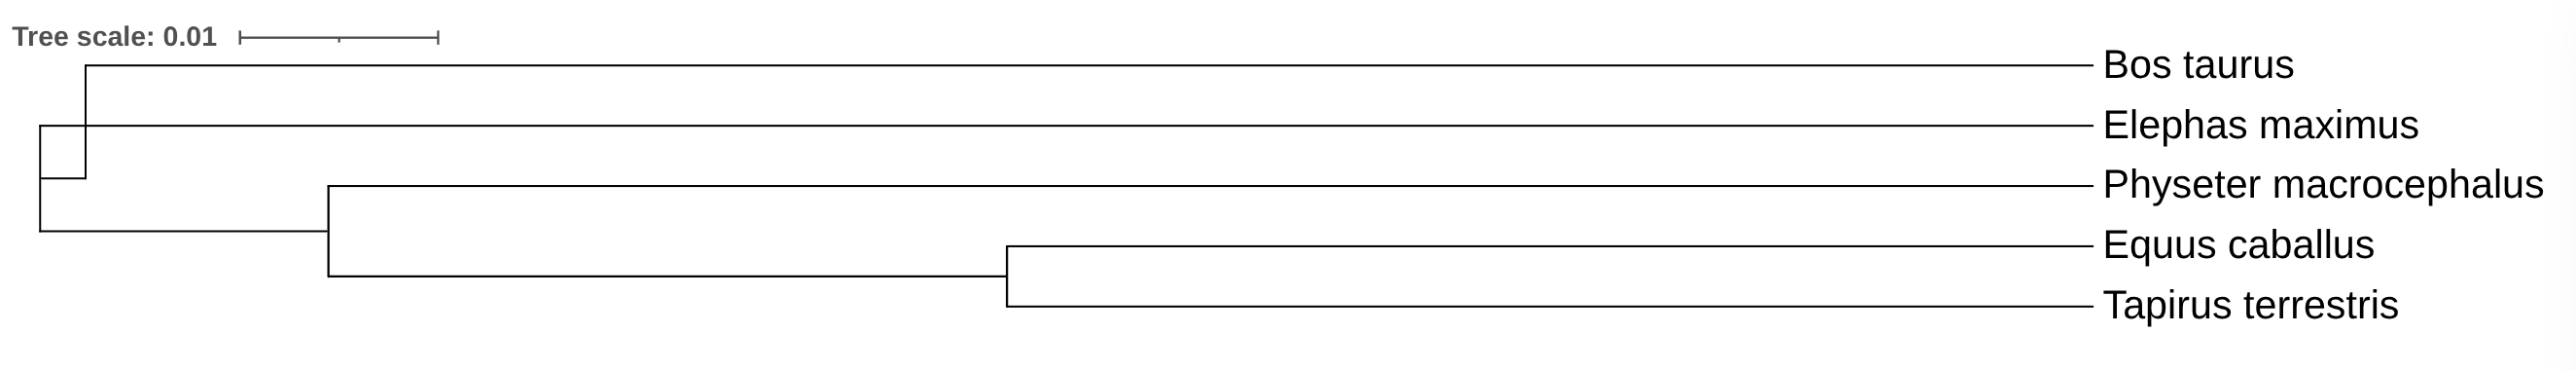

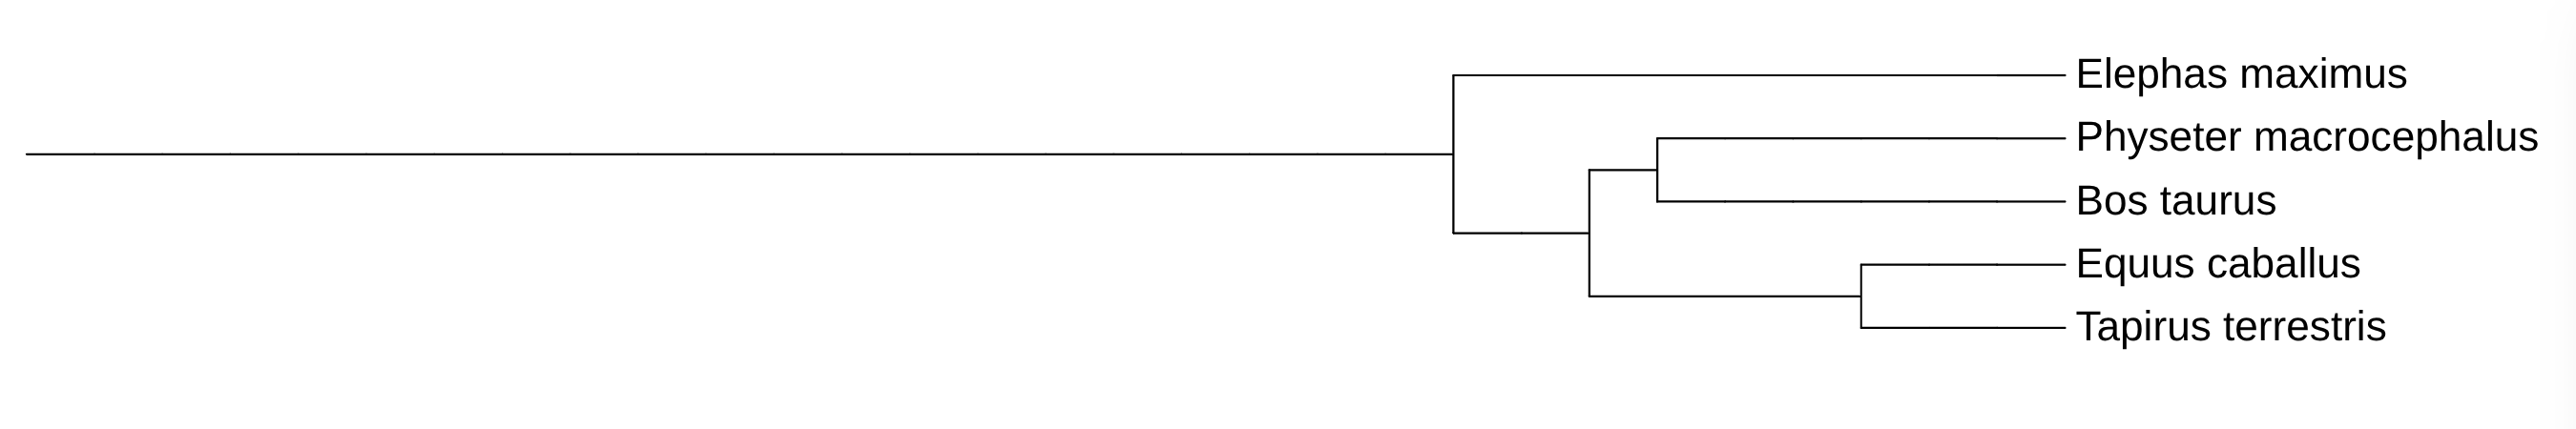

## Часть 2 — MEGA и коронавирус — 4 балла


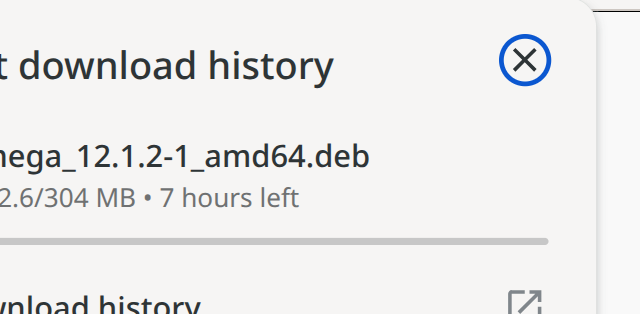

пупупу

ну это же то же самое множественное выравнивание и то же самое построение деревьев так что справимся)

In [ ]:
!cat S_prot_sequences.fasta

In [15]:
!clustalo -i S_prot_sequences.fasta  -o covid_clustal.aln --outfmt=clu --guidetree-out=covid.dnd  --force

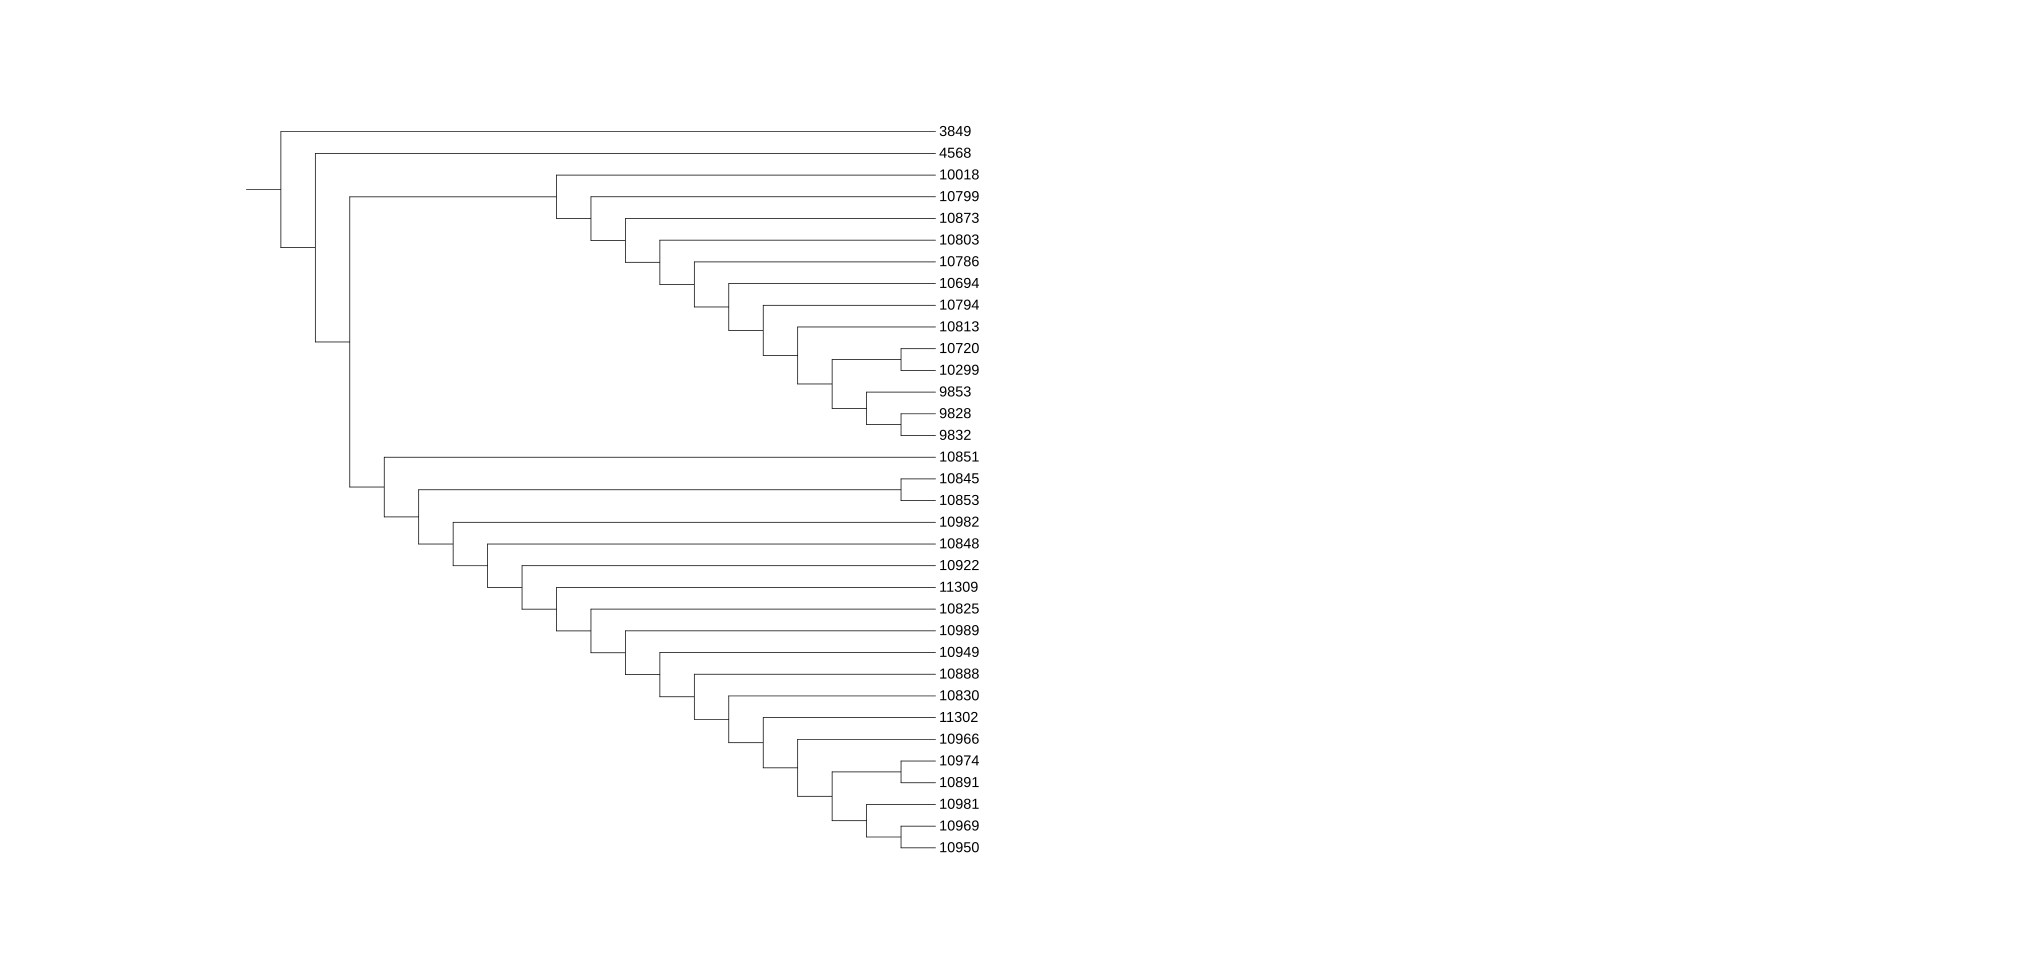

У этих фаста файлов нет ни аннотации, ничего, так что ничего стоящего по ним сказать нельзя. Ну да, есть 2 крупные клады и 2 каких-то корневых референсных штамма

Добавим 3 последовательности коронавируса,  из 2021 года из бразилии и южной африки и как контроль Уханьский штамм

In [17]:
!cat S_prot_sequences.fasta wuhan.fasta south_africa.fasta brasil.fasta > corona.fasta

In [18]:
!clustalo -i corona.fasta  -o corona_clustal.aln --outfmt=clu --guidetree-out=corona.dnd  --force

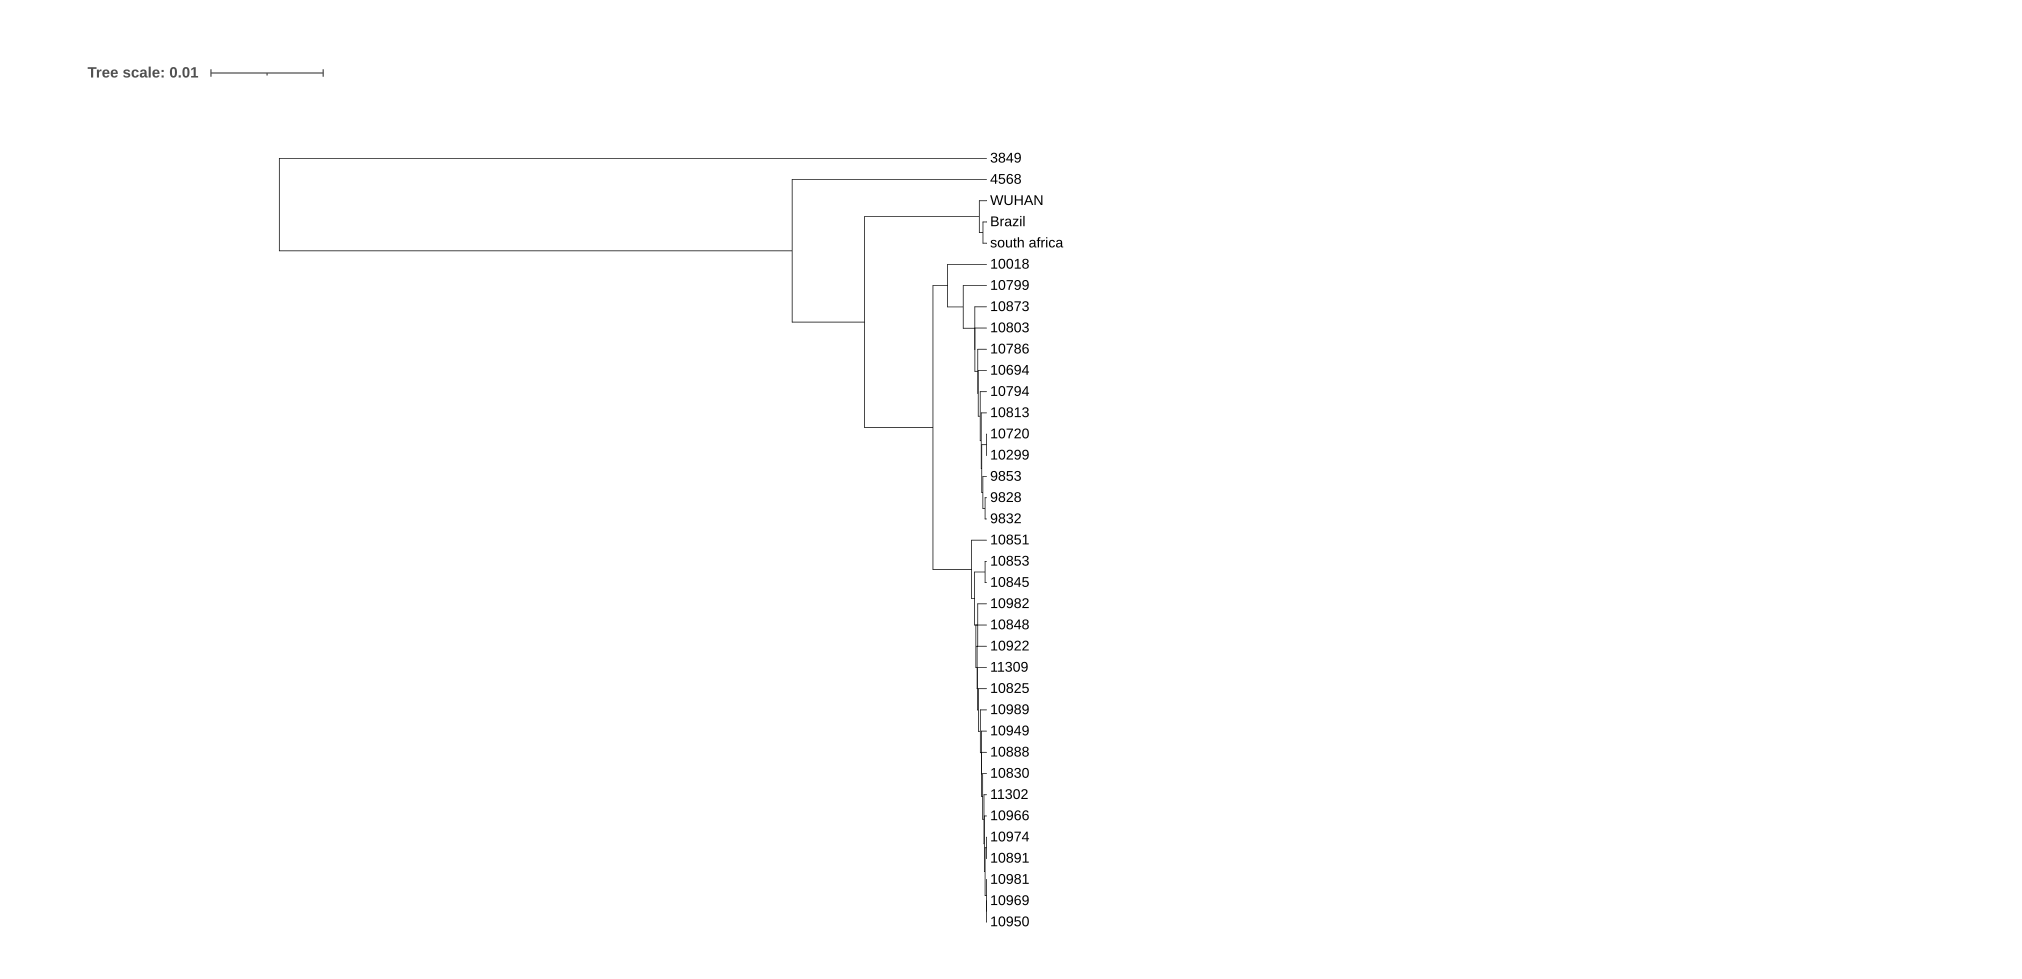

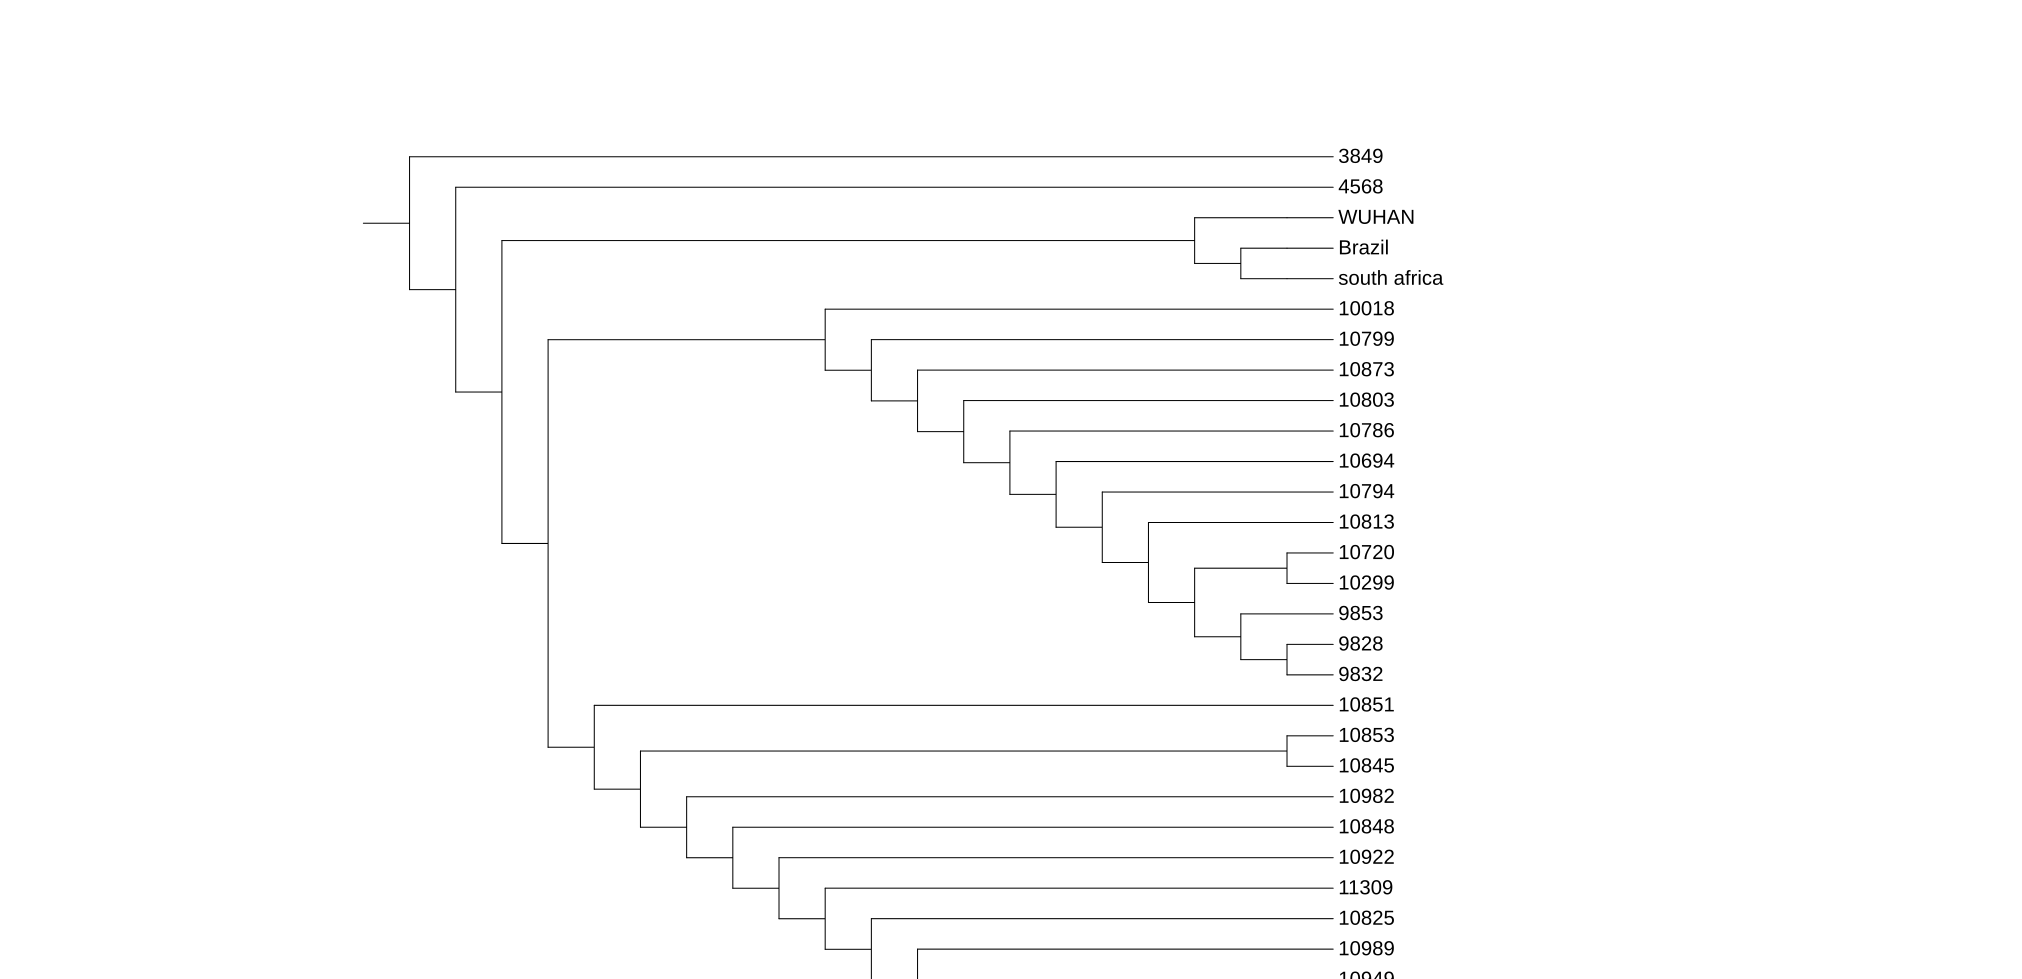

## Часть 3 — BLAST — 3 балла


Забластили, получили что этот участок - родопсин коровы. [тут](https://www.ncbi.nlm.nih.gov/protein/9NYX_B?report=genbank&log$=protalign&blast_rank=1&RID=WJC0KWNZ014)

Затем пробластили снова, указав как вид Homo sapiens, через алгоритм tblastp потому что ищем именно **ген** и в базе транскриптомов, а именно refseq_select_rna с транскриптомом человека.

Нашли ген человеческого родопсина [тутъ](https://www.ncbi.nlm.nih.gov/nucleotide/NM_000539.3?report=genbank&log$=nuclalign&blast_rank=3&RID=WJFDWVNM016)

При его поломке можно получить много болезней, найти их просто - на Uniprot тыкаем в Variant Viewer

1. **Congenital stationary night blindness autosomal dominant 1** — наследственная ночная слепота, при которой нарушается адаптация зрения в темноте из-за дефектов родопсина.

2. **Retinal dystrophy** — прогрессирующее дистрофическое поражение сетчатки, приводящее к ухудшению зрения и фотопсии.

3. **Retinitis pigmentosa 4** — форма пигментного ретинита с накоплением пигмента в сетчатке и прогрессирующей потерей зрения.

4. **Cone-rod dystrophy** — дегенерация сначала колбочковых, затем палочковых клеток сетчатки, приводящая к потере центрального и периферического зрения.

5. **Retinitis punctata albescens** — редкая форма пигментного ретинита с белыми точечными отложениями в сетчатке и ночной слепотой.

Ну теперь скачаем транскриптом) вышло 89 мегабайт на одного светлячка Photinus pyralis 

In [19]:
%cd /home/khokholmongolll/bioinf/hw_bioinformatics/hw2/ncbi_dataset/data/GCF_008802855.1

/home/khokholmongolll/bioinf/hw_bioinformatics/hw2/ncbi_dataset/data/GCF_008802855.1


In [20]:
!TransDecoder.LongOrfs -t rna.fna -m 100

* Running CMD: /home/khokholmongolll/miniconda3/envs/ml/opt/transdecoder/util/compute_base_probs.pl rna.fna 0 > /home/khokholmongolll/bioinf/hw_bioinformatics/hw2/ncbi_dataset/data/GCF_008802855.1/rna.fna.transdecoder_dir/base_freqs.dat


-first extracting base frequencies, we'll need them later.


- extracting ORFs from transcripts.
-total transcripts to examine: 37204
[37200/37204] = 99.99% done    CMD: touch /home/khokholmongolll/bioinf/hw_bioinformatics/hw2/ncbi_dataset/data/GCF_008802855.1/rna.fna.transdecoder_dir.__checkpoints_longorfs/TD.longorfs.ok


#################################
### Done preparing long ORFs.  ###
##################################

	Use file: /home/khokholmongolll/bioinf/hw_bioinformatics/hw2/ncbi_dataset/data/GCF_008802855.1/rna.fna.transdecoder_dir/longest_orfs.pep  for Pfam and/or BlastP searches to enable homology-based coding region identification.

	Then, run TransDecoder.Predict for your final coding region predictions.




In [21]:
!makeblastdb -in rna.fna.transdecoder_dir/longest_orfs.pep -dbtype prot -out pp_luc_db



Building a new DB, current time: 03/29/2026 21:11:51
New DB name:   /home/khokholmongolll/bioinf/hw_bioinformatics/hw2/ncbi_dataset/data/GCF_008802855.1/pp_luc_db
New DB title:  rna.fna.transdecoder_dir/longest_orfs.pep
Sequence type: Protein
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 52937 sequences in 0.567332 seconds.




In [22]:
!wget https://rest.uniprot.org/uniprotkb/P13129.fasta

--2026-03-29 21:16:13--  https://rest.uniprot.org/uniprotkb/P13129.fasta
Resolving rest.uniprot.org (rest.uniprot.org)... 193.62.193.81
Connecting to rest.uniprot.org (rest.uniprot.org)|193.62.193.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 651 [text/plain]
Saving to: ‘P13129.fasta’

P13129.fasta        100%[===================>]     651  --.-KB/s    in 0s      

2026-03-29 21:16:14 (468 MB/s) - ‘P13129.fasta’ saved [651/651]



In [23]:
!blastp -query P13129.fasta  -db pp_luc_db -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore"  -evalue 1e-10 -out blast_luc_hits.txt -num_threads 4

In [24]:
!head -10 blast_luc_hits.txt | cut -f2 | sort -u > top10_luc_ids.txt

In [25]:
!cat top10_luc_ids.txt

XM_031471612.1.p1
XM_031471613.1.p1
XM_031471918.1.p1
XM_031472632.1.p1
XM_031472847.1.p1
XM_031472958.1.p1
XM_031473197.1.p1
XM_031473198.1.p1
XM_031473929.1.p1
XM_031497662.1.p1


In [26]:
!seqtk subseq rna.fna.transdecoder_dir/longest_orfs.pep top10_luc_ids.txt > top10_luciferases.fasta